In [1]:
import pandas as pd
import numpy as np
import mobileDataToolkit.preprocessing_v2 as preprocessing
import utils.helper_func as helper_func

In [2]:
# Load sampled data
df = pd.read_csv('C:\\Users\\stlp\\OneDrive - UW\\GPR\\Data\\seattle_2000_all_obs_preprocessed_sampled.csv')

In [3]:
df.head()

,UID,orig_lat,orig_long,orig_unc,datetime,unix_min,DoW,Year,Month,Day,Week,Hour,WoM,SaM,Holiday
0,017bb1f45ee11018b1cca82711c729999f08ac159c9ffc...,47.555557,-122.050186,65.0,2019-12-31 06:31:49,0,1,2019,12,31,1,6,5,23509,0
1,017bb1f45ee11018b1cca82711c729999f08ac159c9ffc...,47.551100,-122.052466,65.0,2019-12-31 06:53:18,21,1,2019,12,31,1,6,5,24798,0
2,017bb1f45ee11018b1cca82711c729999f08ac159c9ffc...,47.551393,-122.053351,65.0,2019-12-31 07:08:22,36,1,2019,12,31,1,7,5,25702,0
3,017bb1f45ee11018b1cca82711c729999f08ac159c9ffc...,47.551065,-122.052334,65.0,2019-12-31 07:18:00,46,1,2019,12,31,1,7,5,26280,0
4,017bb1f45ee11018b1cca82711c729999f08ac159c9ffc...,47.555557,-122.050186,65.0,2019-12-31 07:19:26,47,1,2019,12,31,1,7,5,26366,0


In [4]:
mod = preprocessing.dp_MultiTrip(df)
mod.chooseUser(df.UID.unique()[0])

In [5]:
# Add datetime column without time
mod.data['date'] = pd.to_datetime(mod.data['datetime']).dt.date

# Check which days in April have the most observations
mod.data[pd.to_datetime(mod.data['datetime']).dt.month == 4].groupby('date').count().sort_values('datetime', ascending=False)['UID'].head()

C:\Users\stlp\AppData\Local\Temp\ipykernel_10028\4107106159.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  mod.data['date'] = pd.to_datetime(mod.data['datetime']).dt.date


date
2020-04-30    297
2020-04-22    284
2020-04-03    247
2020-04-08    229
2020-04-29    213
Name: UID, dtype: int64

In [6]:
# Choose the day with the most observations as our test day
test_day = mod.data[pd.to_datetime(mod.data['datetime']).dt.month == 4].groupby('date').count().sort_values('datetime', ascending=False).index[0]

# Check the hourly sampling distribution for our test day
mod.data[mod.data['date'] == test_day].groupby(pd.to_datetime(mod.data['datetime']).dt.hour).count()['UID'].sort_values(ascending=False)

datetime
12    88
2     59
3     32
0     32
13    20
1     18
5      5
4      4
9      4
17     3
22     3
7      3
20     3
18     3
16     3
21     2
19     2
23     2
15     2
11     2
10     2
8      2
6      2
14     1
Name: UID, dtype: int64

In [7]:
mod.data[mod.data['date'] == test_day].groupby(pd.to_datetime(mod.data['datetime']).dt.hour).count()['UID'].sort_values(ascending=False).index[:2]

Int64Index([12, 2], dtype='int64', name='datetime')

In [8]:
# Choose three hours with the most observations as our test hours
test_hours = mod.data[mod.data['date'] == test_day].groupby(pd.to_datetime(mod.data['datetime']).dt.hour).count()['UID'].sort_values(ascending=False).index[:3]

# Segment dataset accordingly
mod.subsetByTime(starttime='{} {}'.format(str(test_day), str(test_hours[0]) + ':00:00'), endtime='{} {}'.format(str(test_day), str(test_hours[-1]) + ':00:00'))

,index,UID,orig_lat,orig_long,orig_unc,datetime,unix_min,DoW,Year,Month,Day,Week,Hour,WoM,SaM,Holiday,date
0,34417,017bb1f45ee11018b1cca82711c729999f08ac159c9ffc...,47.555557,-122.050186,65.0,2020-04-30 12:09:51,174518,3,2020,4,30,18,12,5,43791,0,2020-04-30
1,34418,017bb1f45ee11018b1cca82711c729999f08ac159c9ffc...,47.555557,-122.050186,5.0,2020-04-30 12:10:10,174518,3,2020,4,30,18,12,5,43810,0,2020-04-30
2,34419,017bb1f45ee11018b1cca82711c729999f08ac159c9ffc...,47.550912,-122.054413,10.0,2020-04-30 12:11:09,174519,3,2020,4,30,18,12,5,43869,0,2020-04-30
3,34420,017bb1f45ee11018b1cca82711c729999f08ac159c9ffc...,47.551793,-122.058559,10.0,2020-04-30 12:11:54,174520,3,2020,4,30,18,12,5,43914,0,2020-04-30
4,34421,017bb1f45ee11018b1cca82711c729999f08ac159c9ffc...,47.550927,-122.066730,10.0,2020-04-30 12:12:40,174520,3,2020,4,30,18,12,5,43960,0,2020-04-30
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
127,34544,017bb1f45ee11018b1cca82711c729999f08ac159c9ffc...,47.446320,-122.204887,65.0,2020-04-30 22:15:42,175123,3,2020,4,30,18,22,5,80142,0,2020-04-30
128,34545,017bb1f45ee11018b1cca82711c729999f08ac159c9ffc...,47.446320,-122.204887,65.0,2020-04-30 22:36:44,175144,3,2020,4,30,18,22,5,81404,0,2020-04-30
129,34546,017bb1f45ee11018b1cca82711c729999f08ac159c9ffc...,47.446320,-122.204887,65.0,2020-04-30 22:55:53,175164,3,2020,4,30,18,22,5,82553,0,2020-04-30
130,34547,017bb1f45ee11018b1cca82711c729999f08ac159c9ffc...,47.446320,-122.204887,65.0,2020-04-30 23:16:24,175184,3,2020,4,30,18,23,5,83784,0,2020-04-30


In [9]:
import torch
import gpytorch
from gpytorch.kernels import RQKernel as RQ, RBFKernel as SE, \
PeriodicKernel as PER, ScaleKernel, LinearKernel as LIN, MaternKernel as MAT, \
SpectralMixtureKernel as SMK, PiecewisePolynomialKernel as PPK, CylindricalKernel as CYL
import numpy as np
import matplotlib
from matplotlib import pyplot as plt
from sklearn.preprocessing import StandardScaler, MinMaxScaler
from sklearn.metrics import mean_squared_error
from gpytorch.constraints import Interval
import time

import mobileDataToolkit.methods as methods

In [10]:
mod.data.columns

Index(['index', 'UID', 'orig_lat', 'orig_long', 'orig_unc', 'datetime',
       'unix_min', 'DoW', 'Year', 'Month', 'Day', 'Week', 'Hour', 'WoM', 'SaM',
       'Holiday', 'date'],
      dtype='object')

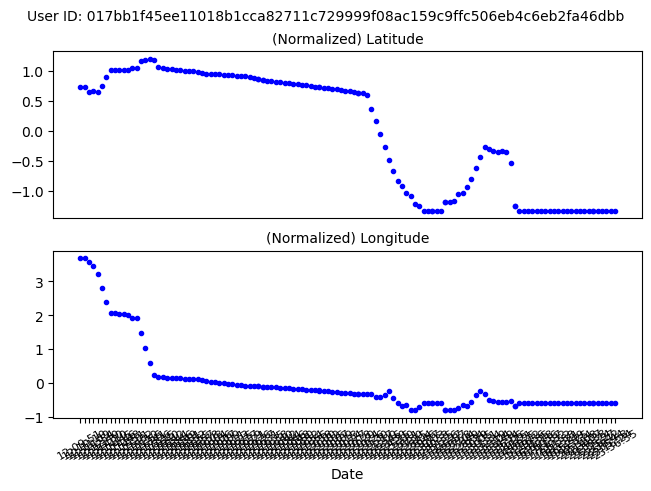

In [11]:
mod.add_NormCoords()

methods.mobVisualize(mod.data)

## Induce gaps
* First, let's check current temporal occupancy

In [12]:
# Check current temporal occupancy
print("Current temporal occupancy: ", mod.tempOcp(bin_len=15, test=False))

Current temporal occupancy:  0.6086956521739131


Ok, we want to reduce this to our target level. The points we remove will be our testing set.

In [13]:
import mobileDataToolkit.analysis as analysis

# Define target temporal occupancy
target_temp_ocp = 0.4

# Simulate gaps in the user's data to match the target level
gapped_user_data, train_index = analysis.simulate_gaps(mod.data, target_temp_ocp, bin_len=15)


New temporal occupancy is 0.391304347826087.


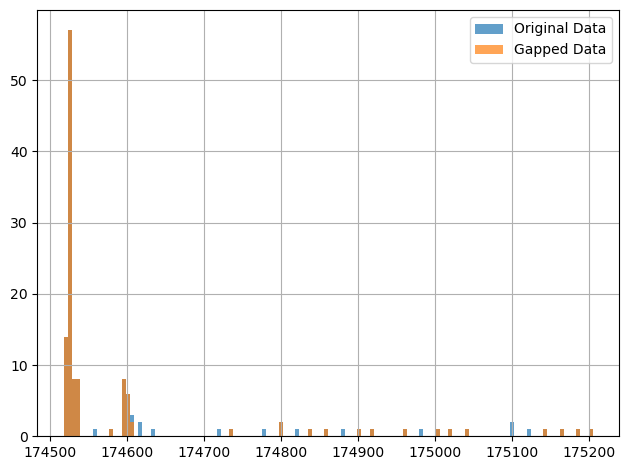

In [14]:
# Visualize the gapped data
mod.data.unix_min.hist(bins=128, label='Original Data', alpha=0.7)
gapped_user_data.unix_min.hist(bins=128, label='Gapped Data', alpha=0.7)
plt.legend()
plt.tight_layout()

plt.show()

In [15]:
train = mod.data.iloc[train_index].copy()
test = mod.data.drop(train_index).copy()

print(len(train))
len(test)

119


13

### Stack the local training set with the longitudinal training data


In [16]:
# Stack local training set with longitudinal training data
longitudinal = preprocessing.dp_MultiTrip(df)
longitudinal.chooseUser(df.UID.unique()[0])

# Add datetime column without time
longitudinal.data['date'] = pd.to_datetime(longitudinal.data['datetime']).dt.date

# Choose every day except the test day as our longitudinal training data
longitudinal.data = longitudinal.data[longitudinal.data['date'] != test_day]

C:\Users\stlp\AppData\Local\Temp\ipykernel_10028\2297175574.py:6: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  longitudinal.data['date'] = pd.to_datetime(longitudinal.data['datetime']).dt.date


In [17]:
# Stack local training set with longitudinal training data
train = pd.concat([train, longitudinal.data])

In [18]:
%cd ..

C:\Users\stlp\GPSImpute


In [19]:
import mobileDataToolkit.methods as methods

In [20]:
helper_func.addDist(train, type=helper_func.haversine_np)
helper_func.addVel(train)
home_lat, home_lon = methods.homeLocv2(train)

Adding distance column to dataframe...
Adding velocity column to dataframe...


### Scikit-Mobility Processing
* Filter by max velocity
* Compress points by spatial heuristic
* Detect stay locations

In [22]:
import skmob.preprocessing.detection

Can't load requested DLL: C:\Program Files\GDAL\gdalplugins\gdal_netCDF.dll
127: The specified procedure could not be found.

Can't load requested DLL: C:\Program Files\GDAL\gdalplugins\gdal_netCDF.dll
127: The specified procedure could not be found.

Can't load requested DLL: C:\Program Files\GDAL\gdalplugins\gdal_netCDF.dll
127: The specified procedure could not be found.

Can't load requested DLL: C:\Program Files\GDAL\gdalplugins\gdal_netCDF.dll
127: The specified procedure could not be found.



In [24]:
%%time
tdf = skmob.TrajDataFrame(train, latitude='orig_lat', longitude='orig_long', datetime='datetime')
f_tdf = skmob.preprocessing.filtering.filter(tdf, max_speed_kmh=400, include_loops=True)
fc_tdf = skmob.preprocessing.compression.compress(f_tdf, spatial_radius_km=0.1) # vary the spatial radius to see how prediction changes
fcs_tdf = skmob.preprocessing.detection.stay_locations(fc_tdf)

Wall time: 7.79 s


In [25]:
n_deleted_points = len(tdf) - len(f_tdf) # number of deleted points during filtering
print(n_deleted_points)

1729


In [27]:
n_deleted_points = len(f_tdf) - len(fc_tdf) # number of deleted points during compression
n_deleted_points / len(train)

0.550528259749184

In [30]:
m = fcs_tdf.plot_trajectory(max_users=1, start_end_markers=False)
#fcs_tdf.plot_stops(map_f=m)

C:\Users\stlp\scikit-mobility\skmob\core\trajectorydataframe.py:689: UserWarning: If necessary, trajectories will be down-sampled to have at most `max_points` points. To avoid this, specify `max_points=None`.
  return plot.plot_trajectory(


In [33]:
import skmob.preprocessing.clustering

In [32]:
fcsc_tdf = skmob.preprocessing.clustering.cluster(fcs_tdf, cluster_radius_km=0.2, min_samples=1)
m2 = fcsc_tdf.plot_trajectory(max_users=1, start_end_markers=False)
#fcsc_tdf.plot_stops(map_f=m2)

C:\Users\stlp\AppData\Local\Temp\ipykernel_10028\1354705256.py:1: DeprecationWarning: This method will be deprecated in version 2.0. Instead, use the dbscan() method.
  fcsc_tdf = skmob.preprocessing.clustering.cluster(fcs_tdf, cluster_radius_km=0.2, min_samples=1)
C:\Users\stlp\scikit-mobility\skmob\core\trajectorydataframe.py:689: UserWarning: If necessary, trajectories will be down-sampled to have at most `max_points` points. To avoid this, specify `max_points=None`.
  return plot.plot_trajectory(


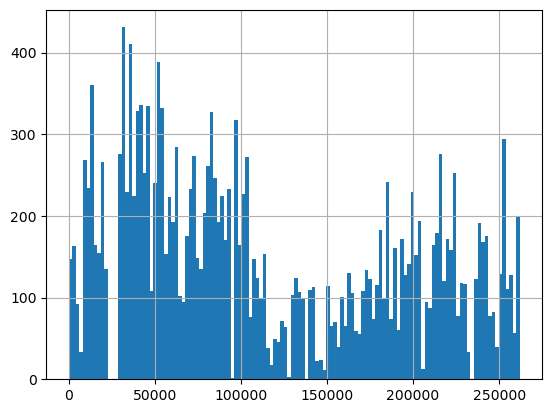

In [39]:
# This is the temporal distribution of the data we will predict with now looks like
fc_tdf.unix_min.hist(bins=128)
plt.show()